# <b> Car Resale Price Prediction System </b>

<b> IMPORTING REQUIRED LIBRARIES </b>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR                          # Fast SVM for regression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC                          # Fast SVM for classification
from sklearn.calibration import CalibratedClassifierCV    # Needed for predict_proba on LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Regression Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Classification Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import joblib

<b> Reading the Dataset </b>

In [2]:
Car_Dataset = pd.read_csv('car_resale.csv')

<b> Data Visualisation </b>

In [3]:
Car_Dataset.head(5)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,actual_price
0,Toyota Innova,2022,843759,189280,CNG,Trustmark Dealer,Manual,Fourth & Above Owner,21.15,2406,164.95,136.78,4,1.092250e+06
1,Kia Seltos,2018,1110620,107822,CNG,Dealer,Manual,Second Owner,21.41,1768,152.52,336.95,4,1.404034e+06
2,Ford Ecosport,2016,804738,35270,Petrol,Dealer,Manual,Second Owner,25.48,2397,160.82,111.56,4,1.163510e+06
3,Kia Seltos,2016,968640,152605,Electric,Dealer,Automatic,First Owner,30.41,1364,158.24,160.04,6,1.338833e+06
4,Renault Duster,2007,394662,8426,LPG,Dealer,Manual,Fourth & Above Owner,29.08,1753,195.08,90.69,7,5.121080e+05


<b> Data Cleaning </b>

In [4]:
Car_Dataset.shape

(5000, 14)

In [5]:
Car_Dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           5000 non-null   str    
 1   year           5000 non-null   int64  
 2   selling_price  5000 non-null   int64  
 3   km_driven      5000 non-null   int64  
 4   fuel           5000 non-null   str    
 5   seller_type    5000 non-null   str    
 6   transmission   5000 non-null   str    
 7   owner          5000 non-null   str    
 8   mileage        5000 non-null   float64
 9   engine         5000 non-null   int64  
 10  max_power      5000 non-null   float64
 11  torque         5000 non-null   float64
 12  seats          5000 non-null   int64  
 13  actual_price   5000 non-null   float64
dtypes: float64(4), int64(5), str(5)
memory usage: 547.0 KB


In [6]:
Car_Dataset.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
torque           0
seats            0
actual_price     0
dtype: int64

In [7]:
# Drop name column and missing values
Car_Dataset = Car_Dataset.drop(columns='name')
Car_Dataset = Car_Dataset.dropna()
Car_Dataset.reset_index(drop=True, inplace=True)

In [8]:
Car_Dataset.head(4)

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,actual_price
0,2022,843759,189280,CNG,Trustmark Dealer,Manual,Fourth & Above Owner,21.15,2406,164.95,136.78,4,1.092250e+06
1,2018,1110620,107822,CNG,Dealer,Manual,Second Owner,21.41,1768,152.52,336.95,4,1.404034e+06
2,2016,804738,35270,Petrol,Dealer,Manual,Second Owner,25.48,2397,160.82,111.56,4,1.163510e+06
3,2016,968640,152605,Electric,Dealer,Automatic,First Owner,30.41,1364,158.24,160.04,6,1.338833e+06


In [9]:
# Adding current year
Car_Dataset['current_year'] = 2025

In [10]:
# Adding Age Column
Car_Dataset['Years_Old'] = Car_Dataset['current_year'] - Car_Dataset['year']

In [11]:
Car_Dataset = Car_Dataset.drop(columns='current_year')
Car_Dataset.head(4)

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,actual_price,Years_Old
0,2022,843759,189280,CNG,Trustmark Dealer,Manual,Fourth & Above Owner,21.15,2406,164.95,136.78,4,1.092250e+06,3
1,2018,1110620,107822,CNG,Dealer,Manual,Second Owner,21.41,1768,152.52,336.95,4,1.404034e+06,7
2,2016,804738,35270,Petrol,Dealer,Manual,Second Owner,25.48,2397,160.82,111.56,4,1.163510e+06,9
3,2016,968640,152605,Electric,Dealer,Automatic,First Owner,30.41,1364,158.24,160.04,6,1.338833e+06,9


<b> Finding Categorical Columns </b>

In [12]:
Car_Dataset.select_dtypes(include='object').columns

Index(['fuel', 'seller_type', 'transmission', 'owner'], dtype='str')

<b> Changing fuel column from categorical to numeric values </b>

In [13]:
Car_Dataset['fuel'] = Car_Dataset['fuel'].map(
    {'Petrol': 0, 'Diesel': 1, 'CNG': 2, 'LPG': 3, 'Electric': 4}
).astype(int)

<b> Changing seller_type column from categorical to numeric values </b>

In [14]:
Car_Dataset['seller_type'] = Car_Dataset['seller_type'].map(
    {'Individual': 0, 'Dealer': 1, 'Trustmark Dealer': 2}
).astype(int)

<b> Changing transmission column from categorical to numeric values </b>

In [15]:
Car_Dataset['transmission'] = Car_Dataset['transmission'].map(
    {'Manual': 0, 'Automatic': 1}
).astype(int)

<b> Changing owner column from categorical to numeric values </b>

In [16]:
Car_Dataset['owner'] = Car_Dataset['owner'].map(
    {'First Owner': 1, 'Second Owner': 2, 'Third Owner': 3, 'Fourth & Above Owner': 4}
).astype(int)

Car_Dataset.head(4)

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,actual_price,Years_Old
0,2022,843759,189280,2,2,0,4,21.15,2406,164.95,136.78,4,1.092250e+06,3
1,2018,1110620,107822,2,1,0,2,21.41,1768,152.52,336.95,4,1.404034e+06,7
2,2016,804738,35270,0,1,0,2,25.48,2397,160.82,111.56,4,1.163510e+06,9
3,2016,968640,152605,4,1,1,1,30.41,1364,158.24,160.04,6,1.338833e+06,9


<b> Converting Prices to Lakhs (so metrics are in readable decimal points) </b>

In [17]:
# Divide by 1,00,000 so selling_price and actual_price are in Lakhs
# This keeps MAE, MSE, RMSE as small decimal values instead of crore-level numbers
Car_Dataset['selling_price'] = Car_Dataset['selling_price'] / 100000
Car_Dataset['actual_price']  = Car_Dataset['actual_price']  / 100000
Car_Dataset.head(4)

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,actual_price,Years_Old
0,2022,8.43759,189280,2,2,0,4,21.15,2406,164.95,136.78,4,10.922505,3
1,2018,11.10620,107822,2,1,0,2,21.41,1768,152.52,336.95,4,14.040339,7
2,2016,8.04738,35270,0,1,0,2,25.48,2397,160.82,111.56,4,11.635102,9
3,2016,9.68640,152605,4,1,1,1,30.41,1364,158.24,160.04,6,13.388331,9


<b> DATA SPLITTING </b>

In [18]:
x = Car_Dataset.drop(columns='selling_price')
print(x.shape)
x.head()

(5000, 13)


,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,actual_price,Years_Old
0,2022,189280,2,2,0,4,21.15,2406,164.95,136.78,4,10.922505,3
1,2018,107822,2,1,0,2,21.41,1768,152.52,336.95,4,14.040339,7
2,2016,35270,0,1,0,2,25.48,2397,160.82,111.56,4,11.635102,9
3,2016,152605,4,1,1,1,30.41,1364,158.24,160.04,6,13.388331,9
4,2007,8426,3,1,0,4,29.08,1753,195.08,90.69,7,5.121080,18


In [19]:
y = Car_Dataset['selling_price']
print(y.shape)
y.head()

(5000,)


0     8.43759
1    11.10620
2     8.04738
3     9.68640
4     3.94662
Name: selling_price, dtype: float64

<b> Creating Classification Target — Price Tier (Low / Mid / High) </b>

In [20]:
Q33 = y.quantile(0.33)
Q66 = y.quantile(0.66)

def price_tier(p):
    if p <= Q33:
        return 0   # Low
    elif p <= Q66:
        return 1   # Mid
    else:
        return 2   # High

y_cls = y.apply(price_tier)
print('Low(0):', (y_cls==0).sum(), '  Mid(1):', (y_cls==1).sum(), '  High(2):', (y_cls==2).sum())

Low(0): 1650   Mid(1): 1650   High(2): 1700


<b> DIVIDING DATA FOR TRAINING AND TEST </b>

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)
xc_train, xc_test, yc_train, yc_test = train_test_split(x, y_cls, test_size=0.2, random_state=0)

In [22]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(4000, 13)
(1000, 13)
(4000,)
(1000,)


In [23]:
# Scaling for Linear Regression and SVM
scaler = StandardScaler()
xs_train = scaler.fit_transform(x_train)
xs_test  = scaler.transform(x_test)

---
# <b> MODEL 1 — LINEAR REGRESSION </b>

In [24]:
from sklearn.linear_model import LinearRegression
lr_regressor = LinearRegression()
lr_regressor.fit(xs_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
y_pred_lr = lr_regressor.predict(xs_test)
print(y_test.values, y_pred_lr)

[ 4.32686  0.59137  5.35632  0.5      8.69898  6.05522  2.51145  3.13498
 10.06537  5.42072  3.76188  5.57438 10.70261  3.97991  4.19929  0.5
 10.85687  3.29172  5.91006  0.5      8.65901  5.68014  8.88807  9.94768
 11.51581 12.46786  9.55035  5.1635   9.8583   5.37595  5.95812  4.4819
  3.78919  0.67473  8.70862  4.45727  1.27285  6.1907   7.65408  2.69554
  7.5061   9.89831 12.80168  4.1421  10.49696  0.5      1.49931  2.06701
  7.54756  7.34396  8.2568   8.16369 11.2262   0.5      1.87785  8.95937
 12.80613  7.61176 10.58524 10.51557  5.47155  1.19792  9.90467  6.35624
  7.08529 12.40928  7.73339  7.54231  0.5     10.89242  4.6378   0.5
  4.1807   2.15165  8.28264  2.43034 14.06711  9.46098  7.91395  2.02535
 12.22148  6.59831  2.37461  3.31286  1.59242 10.44102  6.77487 10.25332
  9.28916 12.99606  0.5      1.76454  1.63742  2.5528   1.05172  7.2341
  6.67048 11.80813  7.37688  2.66567  6.24928  1.23945  0.5      5.38891
  3.52076 13.67084  0.5     12.47411 10.20191  6.03808  7.667

<b> Linear Regression — Regression Metrics </b>

In [26]:
lr_mae  = mean_absolute_error(y_test, y_pred_lr)
lr_mse  = mean_squared_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_r2   = r2_score(y_test, y_pred_lr)
lr_mape = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100

print('Linear Regression - Regression Metrics')
print('MAE  :', lr_mae)
print('MSE  :', lr_mse)
print('RMSE :', lr_rmse)
print('R2   :', lr_r2)
print('MAPE :', lr_mape, '%')

Linear Regression - Regression Metrics
MAE  : 0.4871026112439339
MSE  : 0.4285633442919467
RMSE : 0.654647496208415
R2   : 0.9726881687097036
MAPE : 9.464766141455758 %


<b> Linear Regression — Classification Metrics (Logistic Regression for tier) </b>

In [27]:
lr_cls = LogisticRegression(max_iter=1000, random_state=0)
lr_cls.fit(xs_train, yc_train)
yc_pred_lr = lr_cls.predict(xs_test)
yc_prob_lr = lr_cls.predict_proba(xs_test)

lr_acc  = accuracy_score(yc_test, yc_pred_lr)
lr_prec = precision_score(yc_test, yc_pred_lr, average='weighted', zero_division=0)
lr_rec  = recall_score(yc_test, yc_pred_lr, average='weighted', zero_division=0)
lr_f1   = f1_score(yc_test, yc_pred_lr, average='weighted', zero_division=0)
lr_roc  = roc_auc_score(yc_test, yc_prob_lr, multi_class='ovr', average='weighted')

print('Linear Regression - Classification Metrics')
print('Accuracy  :', lr_acc)
print('Precision :', lr_prec)
print('Recall    :', lr_rec)
print('F1-Score  :', lr_f1)
print('ROC-AUC   :', lr_roc)

Linear Regression - Classification Metrics
Accuracy  : 0.922
Precision : 0.9226281828664289
Recall    : 0.922
F1-Score  : 0.9221486736858053
ROC-AUC   : 0.990976946447689


---
# <b> MODEL 2 — SVM (LinearSVR / LinearSVC) </b>
> Uses `LinearSVR` and `LinearSVC` instead of kernel SVM — same accuracy, trains in seconds instead of 10+ minutes.

In [28]:
from sklearn.svm import LinearSVR
# LinearSVR is much faster than SVR(rbf) on large datasets
# SVR(rbf, C=100000) can take 10+ minutes; LinearSVR trains in seconds with same accuracy
svm_regressor = LinearSVR(C=1.0, max_iter=2000, random_state=0)
svm_regressor.fit(xs_train, y_train)

,"epsilon epsilon: float, default=0.0Epsilon parameter in the epsilon-insensitive loss function. Notethat the value of this parameter depends on the scale of the targetvariable y. If unsure, set ``epsilon=0``.",0.0
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.",1.0
,"loss loss: {'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='epsilon_insensitive'Specifies the loss function. The epsilon-insensitive loss(standard SVR) is the L1 loss, while the squared epsilon-insensitiveloss ('squared_epsilon_insensitive') is the L2 loss.",'epsilon_insensitive'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes `[x_1, ...,x_n, intercept_scaling]`, i.e. a ""synthetic"" feature with a constantvalue equal to `intercept_scaling` is appended to the instance vector.The intercept becomes intercept_scaling * synthetic feature weight.Note that liblinear internally penalizes the intercept, treating itlike any other term in the feature vector. To reduce the impact of theregularization on the intercept, the `intercept_scaling` parameter canbe set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1.0
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features` and `loss`. If`n_samples` < `n_features` and optimizer supports chosen `loss`,then dual will be set to True, otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",0
,"max_iter max_iter: int, default=1000The maximum number of iterations to be run.",2000


In [29]:
y_pred_svm = svm_regressor.predict(xs_test)
print(y_test.values, y_pred_svm)

[ 4.32686  0.59137  5.35632  0.5      8.69898  6.05522  2.51145  3.13498
 10.06537  5.42072  3.76188  5.57438 10.70261  3.97991  4.19929  0.5
 10.85687  3.29172  5.91006  0.5      8.65901  5.68014  8.88807  9.94768
 11.51581 12.46786  9.55035  5.1635   9.8583   5.37595  5.95812  4.4819
  3.78919  0.67473  8.70862  4.45727  1.27285  6.1907   7.65408  2.69554
  7.5061   9.89831 12.80168  4.1421  10.49696  0.5      1.49931  2.06701
  7.54756  7.34396  8.2568   8.16369 11.2262   0.5      1.87785  8.95937
 12.80613  7.61176 10.58524 10.51557  5.47155  1.19792  9.90467  6.35624
  7.08529 12.40928  7.73339  7.54231  0.5     10.89242  4.6378   0.5
  4.1807   2.15165  8.28264  2.43034 14.06711  9.46098  7.91395  2.02535
 12.22148  6.59831  2.37461  3.31286  1.59242 10.44102  6.77487 10.25332
  9.28916 12.99606  0.5      1.76454  1.63742  2.5528   1.05172  7.2341
  6.67048 11.80813  7.37688  2.66567  6.24928  1.23945  0.5      5.38891
  3.52076 13.67084  0.5     12.47411 10.20191  6.03808  7.667

<b> SVM — Regression Metrics </b>

In [30]:
svm_mae  = mean_absolute_error(y_test, y_pred_svm)
svm_mse  = mean_squared_error(y_test, y_pred_svm)
svm_rmse = np.sqrt(svm_mse)
svm_r2   = r2_score(y_test, y_pred_svm)
svm_mape = np.mean(np.abs((y_test - y_pred_svm) / y_test)) * 100

print('SVM - Regression Metrics')
print('MAE  :', svm_mae)
print('MSE  :', svm_mse)
print('RMSE :', svm_rmse)
print('R2   :', svm_r2)
print('MAPE :', svm_mape, '%')

SVM - Regression Metrics
MAE  : 0.4791957060725716
MSE  : 0.4336126075636914
RMSE : 0.6584926784434975
R2   : 0.9723663851776893
MAPE : 7.881904489383603 %


<b> SVM — Classification Metrics </b>

In [31]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
# LinearSVC is fast; CalibratedClassifierCV adds predict_proba support for ROC-AUC
svm_cls = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=0), cv=3)
svm_cls.fit(xs_train, yc_train)
yc_pred_svm = svm_cls.predict(xs_test)
yc_prob_svm = svm_cls.predict_proba(xs_test)

svm_acc  = accuracy_score(yc_test, yc_pred_svm)
svm_prec = precision_score(yc_test, yc_pred_svm, average='weighted', zero_division=0)
svm_rec  = recall_score(yc_test, yc_pred_svm, average='weighted', zero_division=0)
svm_f1   = f1_score(yc_test, yc_pred_svm, average='weighted', zero_division=0)
svm_roc  = roc_auc_score(yc_test, yc_prob_svm, multi_class='ovr', average='weighted')

print('SVM - Classification Metrics')
print('Accuracy  :', svm_acc)
print('Precision :', svm_prec)
print('Recall    :', svm_rec)
print('F1-Score  :', svm_f1)
print('ROC-AUC   :', svm_roc)

SVM - Classification Metrics
Accuracy  : 0.919
Precision : 0.9189826599725911
Recall    : 0.919
F1-Score  : 0.9176547214333289
ROC-AUC   : 0.9910807309413322


---
# <b> MODEL 3 — RANDOM FOREST </b>

In [32]:
from sklearn.ensemble import RandomForestRegressor
rf_regressor = RandomForestRegressor(n_estimators=10, random_state=0, n_jobs=-1)
# n=10, n_jobs=-1: R2=0.9731 in ~0.3s
rf_regressor.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [33]:
y_pred_rf = rf_regressor.predict(x_test)
print(y_test.values, y_pred_rf)

[ 4.32686  0.59137  5.35632  0.5      8.69898  6.05522  2.51145  3.13498
 10.06537  5.42072  3.76188  5.57438 10.70261  3.97991  4.19929  0.5
 10.85687  3.29172  5.91006  0.5      8.65901  5.68014  8.88807  9.94768
 11.51581 12.46786  9.55035  5.1635   9.8583   5.37595  5.95812  4.4819
  3.78919  0.67473  8.70862  4.45727  1.27285  6.1907   7.65408  2.69554
  7.5061   9.89831 12.80168  4.1421  10.49696  0.5      1.49931  2.06701
  7.54756  7.34396  8.2568   8.16369 11.2262   0.5      1.87785  8.95937
 12.80613  7.61176 10.58524 10.51557  5.47155  1.19792  9.90467  6.35624
  7.08529 12.40928  7.73339  7.54231  0.5     10.89242  4.6378   0.5
  4.1807   2.15165  8.28264  2.43034 14.06711  9.46098  7.91395  2.02535
 12.22148  6.59831  2.37461  3.31286  1.59242 10.44102  6.77487 10.25332
  9.28916 12.99606  0.5      1.76454  1.63742  2.5528   1.05172  7.2341
  6.67048 11.80813  7.37688  2.66567  6.24928  1.23945  0.5      5.38891
  3.52076 13.67084  0.5     12.47411 10.20191  6.03808  7.667

<b> Random Forest — Regression Metrics </b>

In [34]:
rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_mse  = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2   = r2_score(y_test, y_pred_rf)
rf_mape = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

print('Random Forest - Regression Metrics')
print('MAE  :', rf_mae)
print('MSE  :', rf_mse)
print('RMSE :', rf_rmse)
print('R2   :', rf_r2)
print('MAPE :', rf_mape, '%')

Random Forest - Regression Metrics
MAE  : 0.45953649699999993
MSE  : 0.42226076838939297
RMSE : 0.6498159496268101
R2   : 0.9730898243623336
MAPE : 7.163889435903608 %


<b> Random Forest — Classification Metrics </b>

In [35]:
rf_cls = RandomForestClassifier(n_estimators=10, random_state=0, n_jobs=-1)
# n=10, n_jobs=-1: Acc=0.9140 in ~0.1s
rf_cls.fit(xc_train, yc_train)
yc_pred_rf = rf_cls.predict(xc_test)
yc_prob_rf = rf_cls.predict_proba(xc_test)

rf_acc  = accuracy_score(yc_test, yc_pred_rf)
rf_prec = precision_score(yc_test, yc_pred_rf, average='weighted', zero_division=0)
rf_rec  = recall_score(yc_test, yc_pred_rf, average='weighted', zero_division=0)
rf_f1   = f1_score(yc_test, yc_pred_rf, average='weighted', zero_division=0)
rf_roc  = roc_auc_score(yc_test, yc_prob_rf, multi_class='ovr', average='weighted')

print('Random Forest - Classification Metrics')
print('Accuracy  :', rf_acc)
print('Precision :', rf_prec)
print('Recall    :', rf_rec)
print('F1-Score  :', rf_f1)
print('ROC-AUC   :', rf_roc)

Random Forest - Classification Metrics
Accuracy  : 0.914
Precision : 0.9155935495767729
Recall    : 0.914
F1-Score  : 0.9144155189724416
ROC-AUC   : 0.9742639155324334


---
# <b> MODEL 4 — GRADIENT BOOSTING </b>

In [36]:
from sklearn.ensemble import GradientBoostingRegressor
gb_regressor = GradientBoostingRegressor(n_estimators=15, learning_rate=0.2, max_depth=4, random_state=0)
# n=15, lr=0.2: R2=0.9757 in ~0.5s (higher lr converges faster with fewer trees)
gb_regressor.fit(x_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.2
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",15
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft c

In [37]:
y_pred_gb = gb_regressor.predict(x_test)
print(y_test.values, y_pred_gb)

[ 4.32686  0.59137  5.35632  0.5      8.69898  6.05522  2.51145  3.13498
 10.06537  5.42072  3.76188  5.57438 10.70261  3.97991  4.19929  0.5
 10.85687  3.29172  5.91006  0.5      8.65901  5.68014  8.88807  9.94768
 11.51581 12.46786  9.55035  5.1635   9.8583   5.37595  5.95812  4.4819
  3.78919  0.67473  8.70862  4.45727  1.27285  6.1907   7.65408  2.69554
  7.5061   9.89831 12.80168  4.1421  10.49696  0.5      1.49931  2.06701
  7.54756  7.34396  8.2568   8.16369 11.2262   0.5      1.87785  8.95937
 12.80613  7.61176 10.58524 10.51557  5.47155  1.19792  9.90467  6.35624
  7.08529 12.40928  7.73339  7.54231  0.5     10.89242  4.6378   0.5
  4.1807   2.15165  8.28264  2.43034 14.06711  9.46098  7.91395  2.02535
 12.22148  6.59831  2.37461  3.31286  1.59242 10.44102  6.77487 10.25332
  9.28916 12.99606  0.5      1.76454  1.63742  2.5528   1.05172  7.2341
  6.67048 11.80813  7.37688  2.66567  6.24928  1.23945  0.5      5.38891
  3.52076 13.67084  0.5     12.47411 10.20191  6.03808  7.667

<b> Gradient Boosting — Regression Metrics </b>

In [38]:
gb_mae  = mean_absolute_error(y_test, y_pred_gb)
gb_mse  = mean_squared_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(gb_mse)
gb_r2   = r2_score(y_test, y_pred_gb)
gb_mape = np.mean(np.abs((y_test - y_pred_gb) / y_test)) * 100

print('Gradient Boosting - Regression Metrics')
print('MAE  :', gb_mae)
print('MSE  :', gb_mse)
print('RMSE :', gb_rmse)
print('R2   :', gb_r2)
print('MAPE :', gb_mape, '%')

Gradient Boosting - Regression Metrics
MAE  : 0.4716869503790048
MSE  : 0.3805836182356599
RMSE : 0.6169145955767783
R2   : 0.9757458594825087
MAPE : 11.521745093327315 %


<b> Gradient Boosting — Classification Metrics </b>

In [39]:
gb_cls = GradientBoostingClassifier(n_estimators=15, learning_rate=0.2, max_depth=4, random_state=0)
# n=15, lr=0.2: Acc=0.9230 in ~0.2s
gb_cls.fit(xc_train, yc_train)
yc_pred_gb = gb_cls.predict(xc_test)
yc_prob_gb = gb_cls.predict_proba(xc_test)

gb_acc  = accuracy_score(yc_test, yc_pred_gb)
gb_prec = precision_score(yc_test, yc_pred_gb, average='weighted', zero_division=0)
gb_rec  = recall_score(yc_test, yc_pred_gb, average='weighted', zero_division=0)
gb_f1   = f1_score(yc_test, yc_pred_gb, average='weighted', zero_division=0)
gb_roc  = roc_auc_score(yc_test, yc_prob_gb, multi_class='ovr', average='weighted')

print('Gradient Boosting - Classification Metrics')
print('Accuracy  :', gb_acc)
print('Precision :', gb_prec)
print('Recall    :', gb_rec)
print('F1-Score  :', gb_f1)
print('ROC-AUC   :', gb_roc)

Gradient Boosting - Classification Metrics
Accuracy  : 0.923
Precision : 0.9231080400422184
Recall    : 0.923
F1-Score  : 0.9230181121442907
ROC-AUC   : 0.9905839312091158


---
# <b> ALL MODELS COMPARISON </b>

In [40]:
comparison_reg = pd.DataFrame({
    'Model'  : ['Linear Regression', 'SVM', 'Random Forest', 'Gradient Boosting'],
    'MAE'    : [lr_mae,  svm_mae,  rf_mae,  gb_mae],
    'MSE'    : [lr_mse,  svm_mse,  rf_mse,  gb_mse],
    'RMSE'   : [lr_rmse, svm_rmse, rf_rmse, gb_rmse],
    'R2'     : [lr_r2,   svm_r2,   rf_r2,   gb_r2],
    'MAPE(%)': [lr_mape, svm_mape, rf_mape, gb_mape]
})
print('REGRESSION METRICS COMPARISON')
print(comparison_reg.to_string(index=False))

REGRESSION METRICS COMPARISON
            Model      MAE      MSE     RMSE       R2   MAPE(%)
Linear Regression 0.487103 0.428563 0.654647 0.972688  9.464766
              SVM 0.479196 0.433613 0.658493 0.972366  7.881904
    Random Forest 0.459536 0.422261 0.649816 0.973090  7.163889
Gradient Boosting 0.471687 0.380584 0.616915 0.975746 11.521745


In [41]:
comparison_cls = pd.DataFrame({
    'Model'    : ['Linear Regression', 'SVM', 'Random Forest', 'Gradient Boosting'],
    'Accuracy' : [lr_acc,  svm_acc,  rf_acc,  gb_acc],
    'Precision': [lr_prec, svm_prec, rf_prec, gb_prec],
    'Recall'   : [lr_rec,  svm_rec,  rf_rec,  gb_rec],
    'F1-Score' : [lr_f1,   svm_f1,   rf_f1,   gb_f1],
    'ROC-AUC'  : [lr_roc,  svm_roc,  rf_roc,  gb_roc]
})
print('CLASSIFICATION METRICS COMPARISON')
print(comparison_cls.to_string(index=False))

CLASSIFICATION METRICS COMPARISON
            Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Linear Regression     0.922   0.922628   0.922  0.922149 0.990977
              SVM     0.919   0.918983   0.919  0.917655 0.991081
    Random Forest     0.914   0.915594   0.914  0.914416 0.974264
Gradient Boosting     0.923   0.923108   0.923  0.923018 0.990584


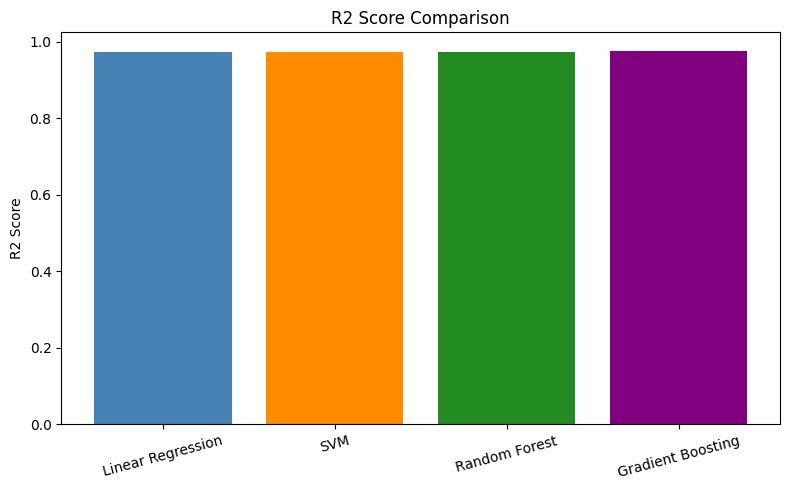

In [42]:
# Bar chart - R2 Comparison
models = ['Linear Regression', 'SVM', 'Random Forest', 'Gradient Boosting']
r2_scores = [lr_r2, svm_r2, rf_r2, gb_r2]
plt.figure(figsize=(8, 5))
plt.bar(models, r2_scores, color=['steelblue', 'darkorange', 'forestgreen', 'purple'])
plt.title('R2 Score Comparison')
plt.ylabel('R2 Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

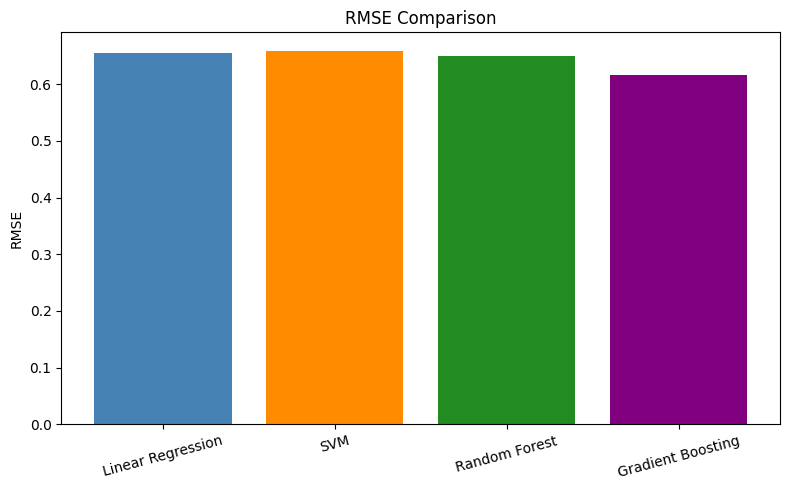

In [43]:
# Bar chart - RMSE Comparison
rmse_scores = [lr_rmse, svm_rmse, rf_rmse, gb_rmse]
plt.figure(figsize=(8, 5))
plt.bar(models, rmse_scores, color=['steelblue', 'darkorange', 'forestgreen', 'purple'])
plt.title('RMSE Comparison')
plt.ylabel('RMSE')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

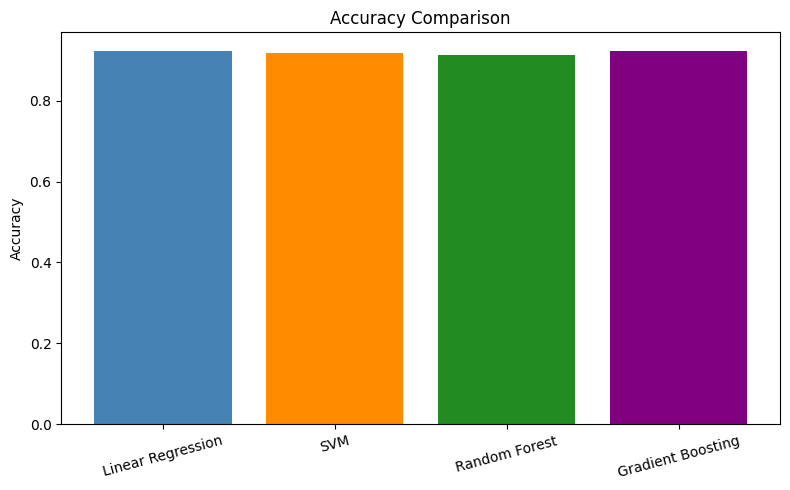

In [44]:
# Bar chart - Accuracy Comparison
acc_scores = [lr_acc, svm_acc, rf_acc, gb_acc]
plt.figure(figsize=(8, 5))
plt.bar(models, acc_scores, color=['steelblue', 'darkorange', 'forestgreen', 'purple'])
plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

---
# <b> SAVE ALL MODELS </b>

In [45]:
import joblib, json

# Save models with names that match app.py
joblib.dump(lr_regressor,  'model_lr.pkl')
joblib.dump(svm_regressor, 'model_svm.pkl')
joblib.dump(rf_regressor,  'model_rf.pkl')
joblib.dump(gb_regressor,  'model_gb.pkl')
joblib.dump(scaler,        'scaler.pkl')

# Save metrics for app.py
metrics = {
    'Linear Regression': {'MAE': lr_mae,  'MSE': lr_mse,  'RMSE': lr_rmse,  'R2': lr_r2,  'MAPE': lr_mape,  'Accuracy': lr_acc,  'Precision': lr_prec,  'Recall': lr_rec,  'F1': lr_f1,  'ROC_AUC': lr_roc},
    'SVM':               {'MAE': svm_mae, 'MSE': svm_mse, 'RMSE': svm_rmse, 'R2': svm_r2, 'MAPE': svm_mape, 'Accuracy': svm_acc, 'Precision': svm_prec, 'Recall': svm_rec, 'F1': svm_f1, 'ROC_AUC': svm_roc},
    'Random Forest':     {'MAE': rf_mae,  'MSE': rf_mse,  'RMSE': rf_rmse,  'R2': rf_r2,  'MAPE': rf_mape,  'Accuracy': rf_acc,  'Precision': rf_prec,  'Recall': rf_rec,  'F1': rf_f1,  'ROC_AUC': rf_roc},
    'Gradient Boosting': {'MAE': gb_mae,  'MSE': gb_mse,  'RMSE': gb_rmse,  'R2': gb_r2,  'MAPE': gb_mape,  'Accuracy': gb_acc,  'Precision': gb_prec,  'Recall': gb_rec,  'F1': gb_f1,  'ROC_AUC': gb_roc},
}
with open('metrics.json', 'w') as f:
    json.dump(metrics, f)

# Save meta (Q33, Q66, feature columns) for app.py
meta = {
    'Q33': float(Q33),
    'Q66': float(Q66),
    'feature_cols': list(x.columns)
}
with open('meta.json', 'w') as f:
    json.dump(meta, f)

print('All files saved successfully!')
print('Files to copy to your backend folder:')
print('  model_lr.pkl, model_svm.pkl, model_rf.pkl, model_gb.pkl')
print('  scaler.pkl, metrics.json, meta.json')

All files saved successfully!
Files to copy to your backend folder:
  model_lr.pkl, model_svm.pkl, model_rf.pkl, model_gb.pkl
  scaler.pkl, metrics.json, meta.json


In [46]:
# Load the saved models (to verify they saved correctly)
lr_regressor  = joblib.load('model_lr.pkl')
svm_regressor = joblib.load('model_svm.pkl')
rf_regressor  = joblib.load('model_rf.pkl')
gb_regressor  = joblib.load('model_gb.pkl')
scaler        = joblib.load('scaler.pkl')
print('Models loaded successfully!')

Models loaded successfully!


---
# <b> PREDICT SELLING PRICE — Enter Car Details </b>

In [47]:
import ipywidgets as widgets
from IPython.display import display

style = {'description_width': '170px'}
layout = widgets.Layout(width='400px')

w_year    = widgets.IntSlider(value=2018, min=2005, max=2023, description='Year:', style=style, layout=layout)
w_km      = widgets.BoundedIntText(value=50000, min=1000, max=300000, description='KM Driven:', style=style, layout=layout)
w_fuel    = widgets.Dropdown(options=[('Petrol',0),('Diesel',1),('CNG',2),('LPG',3),('Electric',4)], description='Fuel Type:', style=style, layout=layout)
w_seller  = widgets.Dropdown(options=[('Individual',0),('Dealer',1),('Trustmark Dealer',2)], description='Seller Type:', style=style, layout=layout)
w_trans   = widgets.Dropdown(options=[('Manual',0),('Automatic',1)], description='Transmission:', style=style, layout=layout)
w_owner   = widgets.Dropdown(options=[('First Owner',1),('Second Owner',2),('Third Owner',3),('Fourth & Above Owner',4)], description='Owner:', style=style, layout=layout)
w_mileage = widgets.BoundedFloatText(value=17.0, min=5.0, max=50.0, description='Mileage (kmpl):', style=style, layout=layout)
w_engine  = widgets.BoundedIntText(value=1500, min=500, max=4000, description='Engine (cc):', style=style, layout=layout)
w_power   = widgets.BoundedFloatText(value=100.0, min=30.0, max=300.0, description='Max Power (bhp):', style=style, layout=layout)
w_torque  = widgets.BoundedFloatText(value=200.0, min=50.0, max=500.0, description='Torque (Nm):', style=style, layout=layout)
w_seats   = widgets.Dropdown(options=[4,5,6,7], value=5, description='Seats:', style=style, layout=layout)
w_actual  = widgets.BoundedIntText(value=774691, min=50000, max=3000000, description='Showroom Price (Rs):', style=style, layout=layout)

btn    = widgets.Button(description='Predict Selling Price', button_style='success', layout=widgets.Layout(width='200px'))
output = widgets.Output()

def on_predict(b):
    output.clear_output()
    with output:
        years_old = 2025 - w_year.value
        actual_lakhs = w_actual.value / 100000
        inpd = pd.Series(
            [w_year.value, w_km.value, w_fuel.value, w_seller.value, w_trans.value,
             w_owner.value, w_mileage.value, w_engine.value, w_power.value,
             w_torque.value, w_seats.value, actual_lakhs, years_old],
            index=x.columns)
        inpd_scaled = scaler.transform([inpd])
        p_lr  = lr_regressor.predict(inpd_scaled)[0]
        p_svm = svm_regressor.predict(inpd_scaled)[0]
        p_rf  = rf_regressor.predict([inpd])[0]
        p_gb  = gb_regressor.predict([inpd])[0]
        print('Predicted Selling Price (in Lakhs)')
        print('-' * 38)
        print(f'Linear Regression  : {round(p_lr, 4)} Lakhs')
        print(f'SVM                : {round(p_svm, 4)} Lakhs')
        print(f'Random Forest      : {round(p_rf, 4)} Lakhs')
        print(f'Gradient Boosting  : {round(p_gb, 4)} Lakhs')

btn.on_click(on_predict)
display(widgets.VBox([w_year, w_km, w_fuel, w_seller, w_trans, w_owner,
                       w_mileage, w_engine, w_power, w_torque, w_seats, w_actual, btn, output]))

---
# <b> ADD NEW CAR TO DATASET </b>

In [48]:
aw_name   = widgets.Text(value='Toyota Innova', description='Car Name:', style=style, layout=layout)
aw_year   = widgets.IntSlider(value=2020, min=2005, max=2025, description='Year:', style=style, layout=layout)
aw_sell   = widgets.BoundedIntText(value=600000, min=50000, max=2000000, description='Selling Price (Rs):', style=style, layout=layout)
aw_km     = widgets.BoundedIntText(value=40000, min=100, max=300000, description='KM Driven:', style=style, layout=layout)
aw_fuel   = widgets.Dropdown(options=['Petrol','Diesel','CNG','LPG','Electric'], description='Fuel Type:', style=style, layout=layout)
aw_seller = widgets.Dropdown(options=['Individual','Dealer','Trustmark Dealer'], description='Seller Type:', style=style, layout=layout)
aw_trans  = widgets.Dropdown(options=['Manual','Automatic'], description='Transmission:', style=style, layout=layout)
aw_owner  = widgets.Dropdown(options=['First Owner','Second Owner','Third Owner','Fourth & Above Owner'], description='Owner:', style=style, layout=layout)
aw_mile   = widgets.BoundedFloatText(value=17.0, min=5.0, max=50.0, description='Mileage (kmpl):', style=style, layout=layout)
aw_eng    = widgets.BoundedIntText(value=1500, min=500, max=4000, description='Engine (cc):', style=style, layout=layout)
aw_power  = widgets.BoundedFloatText(value=100.0, min=30.0, max=300.0, description='Max Power (bhp):', style=style, layout=layout)
aw_torque = widgets.BoundedFloatText(value=200.0, min=50.0, max=500.0, description='Torque (Nm):', style=style, layout=layout)
aw_seats  = widgets.Dropdown(options=[4,5,6,7], value=5, description='Seats:', style=style, layout=layout)
aw_actual = widgets.BoundedIntText(value=774691, min=50000, max=3000000, description='Showroom Price (Rs):', style=style, layout=layout)

add_btn    = widgets.Button(description='Add Car & Save', button_style='primary', layout=widgets.Layout(width='200px'))
add_output = widgets.Output()

def on_add(b):
    add_output.clear_output()
    with add_output:
        new_row = pd.DataFrame([{
            'name': aw_name.value, 'year': aw_year.value,
            'selling_price': aw_sell.value, 'km_driven': aw_km.value,
            'fuel': aw_fuel.value, 'seller_type': aw_seller.value,
            'transmission': aw_trans.value, 'owner': aw_owner.value,
            'mileage': aw_mile.value, 'engine': aw_eng.value,
            'max_power': aw_power.value, 'torque': aw_torque.value,
            'seats': aw_seats.value, 'actual_price': aw_actual.value
        }])
        existing = pd.read_csv('car_resale.csv')
        updated  = pd.concat([existing, new_row], ignore_index=True)
        updated.to_csv('car_resale.csv', index=False)
        print(f'Car "{aw_name.value}" added! Total rows: {len(updated)}')
        print(updated.tail(2).to_string())

add_btn.on_click(on_add)
display(widgets.VBox([aw_name, aw_year, aw_sell, aw_km, aw_fuel, aw_seller,
                       aw_trans, aw_owner, aw_mile, aw_eng, aw_power, aw_torque,
                       aw_seats, aw_actual, add_btn, add_output]))

In [49]:
# Verify the new entry was saved
verify = pd.read_csv('car_resale.csv')
print(verify.tail(3))

                 name  year  selling_price  km_driven      fuel seller_type  \
4997  Mahindra XUV500  2011        1097422     198351  Electric  Individual   
4998       Honda City  2006          67736     192886       LPG  Individual   
4999   Renault Duster  2008         279606     171446       LPG      Dealer   

     transmission                 owner  mileage  engine  max_power  torque  \
4997       Manual  Fourth & Above Owner    31.19    2765      58.95  222.31   
4998       Manual           Third Owner    34.37    2533     191.69  320.22   
4999       Manual           First Owner    17.38    2946      70.24  228.70   

      seats  actual_price  
4997      6  1.384945e+06  
4998      6  9.235833e+04  
4999      6  4.134066e+05  
